<a href="https://colab.research.google.com/github/FionaG26/Bioinformatics/blob/main/ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


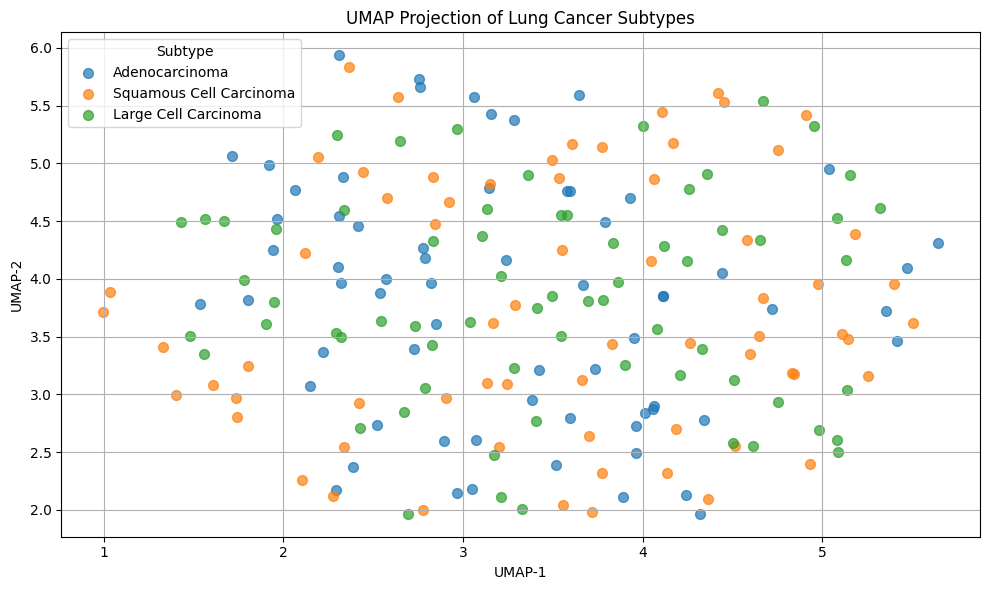

Classification Report:
                         precision    recall  f1-score   support

         Adenocarcinoma       0.42      0.56      0.48         9
Squamous Cell Carcinoma       0.73      0.42      0.53        19
   Large Cell Carcinoma       0.35      0.50      0.41        12

               accuracy                           0.47        40
              macro avg       0.50      0.49      0.47        40
           weighted avg       0.55      0.47      0.48        40



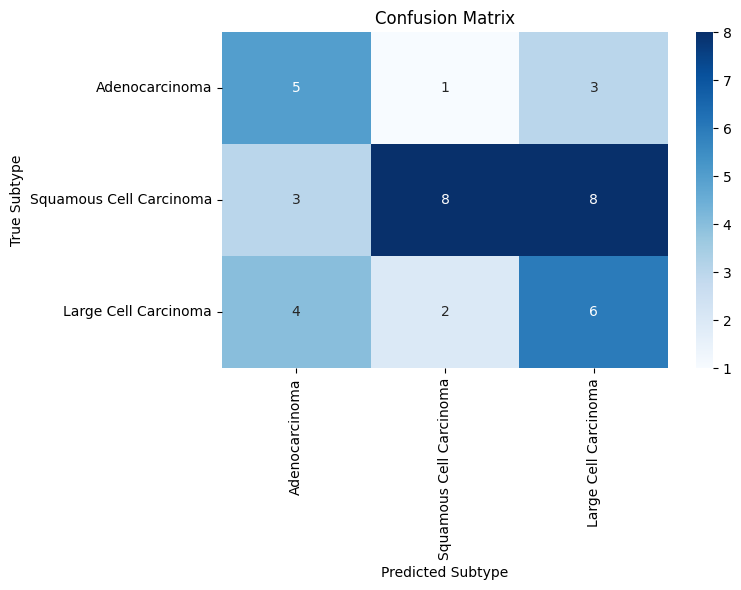

<ipython-input-26-2848121060>:97: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

<Figure size 640x480 with 0 Axes>

In [ ]:
# 📦 Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import umap.umap_ as umap
import gseapy as gp
import shap
from sklearn.cluster import KMeans
from scipy.stats import ttest_ind
import networkx as nx

# 🎲 Simulate Data with Real Gene Symbols
gene_pool = [
    "TP53", "EGFR", "BRCA1", "BRCA2", "KRAS", "PIK3CA", "PTEN", "ALK", "BRAF", "CDKN2A",
    "MYC", "APC", "SMAD4", "NF1", "RB1", "ERBB2", "NOTCH1", "IDH1", "AR", "MET",
    "FGFR1", "NTRK1", "CTNNB1", "FLT3", "JAK2", "TSC2", "VHL", "MLH1", "MDM2", "CDH1",
    "GATA3", "NRAS", "MUC16", "POLE", "SYNE1", "ATM", "ATR", "CHD1", "MAP2K4", "FAT1"
]

rng = np.random.default_rng(42)
n_samples, n_features, n_classes = 200, 1000, 3
simulated_genes = rng.choice(gene_pool, size=n_features, replace=True)

X, y = make_classification(
    n_samples=n_samples,
    n_features=n_features,
    n_informative=50,
    n_redundant=0,
    n_classes=n_classes,
    random_state=42
)

subtypes = np.array(['Adenocarcinoma', 'Squamous Cell Carcinoma', 'Large Cell Carcinoma'])
y_labels = subtypes[y]
df = pd.DataFrame(X, columns=simulated_genes)
df['Subtype'] = y_labels

# 🔬 Preprocessing
X = df.drop(columns=["Subtype"])
y = LabelEncoder().fit_transform(df["Subtype"])

X = np.log2(X - np.min(X.values) + 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

selector = VarianceThreshold(threshold=0.5)
X_sel = selector.fit_transform(X_scaled)

# Recover selected features
mask = selector.get_support()
selected_features = X.columns[mask]
X_sel_df = pd.DataFrame(X_sel, columns=selected_features)

# 🌐 UMAP
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X_umap = umap_model.fit_transform(X_sel_df)

plt.figure(figsize=(10, 6))
for i, subtype in enumerate(subtypes):
    plt.scatter(X_umap[y == i, 0], X_umap[y == i, 1], label=subtype, alpha=0.7, s=50)
plt.title("UMAP Projection of Lung Cancer Subtypes")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend()
plt.grid(True)
plt.show()

# 🎯 Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_sel_df, y, test_size=0.2, random_state=42)

# 🌲 Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=subtypes))

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
            cmap='Blues', xticklabels=subtypes, yticklabels=subtypes)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Subtype")
plt.ylabel("True Subtype")
plt.tight_layout()
plt.show()

# 🧠 SHAP Explainability
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sel_df)

# Get SHAP values for one class (e.g., class 0) — or use expected_value + shap_values combo
class_index = 0
expected_features = X_sel_df.iloc[:100]  # match shape exactly
shap.summary_plot(shap_values[class_index][:100], features=expected_features, feature_names=expected_features.columns.tolist())

# 🔍 KMeans Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans.fit_predict(X_sel_df)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=cluster_labels, palette="Set2")
plt.title("KMeans Clustering on UMAP Projection")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend(title="Cluster")
plt.show()

# 📊 Differential Expression (t-test between subtype 0 and 1)
group0 = df[df["Subtype"] == subtypes[0]].drop(columns="Subtype")
group1 = df[df["Subtype"] == subtypes[1]].drop(columns="Subtype")

t_stat, p_vals = ttest_ind(group0, group1, axis=0, equal_var=False)
de_genes = pd.DataFrame({
    "Gene": group0.columns,
    "p-value": p_vals
}).sort_values("p-value").head(10)
print("\nTop Differentially Expressed Genes:")
print(de_genes)

# 🔬 Pathway Enrichment
top_features = model.feature_importances_
top_indices = np.argsort(top_features)[-100:][::-1]
top_genes = [selected_features[i] for i in top_indices]

enr = gp.enrichr(
    gene_list=top_genes,
    gene_sets=["KEGG_2021_Human", "GO_Biological_Process_2021"],
    organism="Human",
    outdir="enrichment_results",
    no_plot=True
)

print("\nTop Enriched KEGG Pathways:")
print(enr.results[['Term', 'Adjusted P-value']].head(10))

# 🔗 Co-expression Network
corr_matrix = X_sel_df.corr().abs()
high_corr = (corr_matrix > 0.85).astype(int)
np.fill_diagonal(high_corr.values, 0)

G = nx.from_pandas_adjacency(high_corr)
print("\n🧠 Coexpression Network Stats:")
print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")
top_nodes = sorted(G.degree, key=lambda x: x[1], reverse=True)[:5]
print("Top 5 Hub Genes:", [node for node, _ in top_nodes])

# ⏳ Placeholder for Survival Analysis
print("\nSurvival analysis skipped (no survival time data available). Add Kaplan-Meier if time/event data is present.")


✅ Accuracy: 0.9361702127659575

Classification Report:
               precision    recall  f1-score   support

           0       0.88      1.00      0.94        23
           1       1.00      0.88      0.93        24

    accuracy                           0.94        47
   macro avg       0.94      0.94      0.94        47
weighted avg       0.94      0.94      0.94        47


Confusion Matrix:
 [[23  0]
 [ 3 21]]


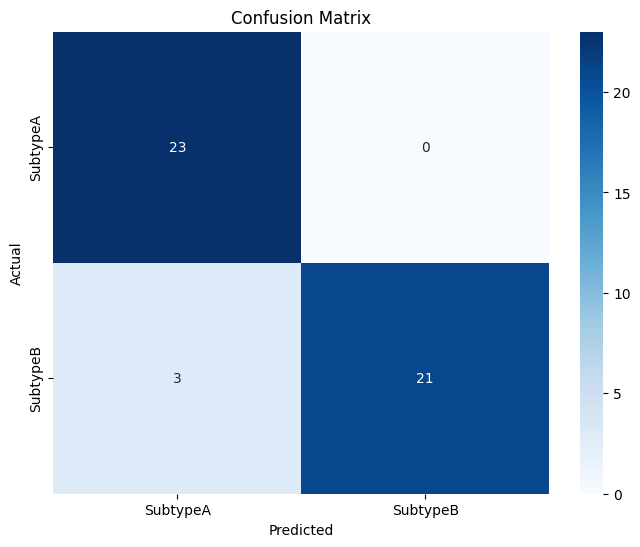

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import gzip

# === Load the expression data ===
file_path = "/content/GSE45827_series_matrix.txt.gz"
df_raw = pd.read_csv(file_path, sep="\t", comment="!", index_col=0).dropna()

# Transpose: rows become samples
df = df_raw.T.copy()
df.index.name = "Sample"

# === TEMP: Assign dummy subtypes (until you get real labels) ===
df["Subtype"] = ["SubtypeA"] * (len(df) // 2) + ["SubtypeB"] * (len(df) - len(df) // 2)

# === Encode and prepare data ===
df = df.dropna(subset=["Subtype"])
le = LabelEncoder()
df["Subtype_encoded"] = le.fit_transform(df["Subtype"])

X = df.drop(["Subtype", "Subtype_encoded"], axis=1).astype(float)
y = df["Subtype_encoded"]

selector = SelectKBest(score_func=f_classif, k=min(1000, X.shape[1]))
X_selected = selector.fit_transform(X, y)

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.3, stratify=y, random_state=42
)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# === Evaluation ===
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# === Plot Confusion Matrix ===
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import gzip
from collections import defaultdict

# === 1. Load file and extract metadata lines ===
file_path = "/content/GSE45827_series_matrix.txt.gz"

meta_lines = []
with gzip.open(file_path, "rt") as f:
    for line in f:
        if line.startswith("!"):
            meta_lines.append(line)
        else:
            break

# === 2. Extract subtype labels from characteristics ===
characteristics_lines = [line for line in meta_lines if "characteristics_ch1" in line.lower()]

sample_info = defaultdict(list)
for line in characteristics_lines:
    entries = line.strip().split("\t")[1:]  # skip label
    for i, val in enumerate(entries):
        sample_info[i].append(val.strip().lower())

subtypes = []
for i in range(len(sample_info)):
    subtype = None
    for field in sample_info[i]:
        if "tumor subtype:" in field:
            subtype = field.split("tumor subtype:")[-1].strip().strip('"')
            break
    subtypes.append(subtype)

print("✅ Subtypes extracted:", len(subtypes))
print("Examples:", subtypes[:5])

# === 3. Load expression data ===
df_raw = pd.read_csv(file_path, sep="\t", comment="!", index_col=0).dropna()
df = df_raw.T.copy()

# Ensure length match before assignment
assert len(df) == len(subtypes), f"Mismatch: {len(df)} samples vs {len(subtypes)} subtypes"

df["Subtype"] = subtypes
df = df.dropna(subset=["Subtype"])

# === 4. Label encoding and ML pipeline ===
le = LabelEncoder()
df["Subtype_encoded"] = le.fit_transform(df["Subtype"])

X = df.drop(["Subtype", "Subtype_encoded"], axis=1).astype(float)
y = df["Subtype_encoded"]

selector = SelectKBest(score_func=f_classif, k=min(1000, X.shape[1]))
X_selected = selector.fit_transform(X, y)

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.3, stratify=y, random_state=42
)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


✅ Subtypes extracted: 0
Examples: []


AssertionError: Mismatch: 155 samples vs 0 subtypes

# New Section

✅ Accuracy: 0.9361702127659575

Classification Report:
               precision    recall  f1-score   support

           0       0.88      1.00      0.94        23
           1       1.00      0.88      0.93        24

    accuracy                           0.94        47
   macro avg       0.94      0.94      0.94        47
weighted avg       0.94      0.94      0.94        47


Confusion Matrix:
 [[23  0]
 [ 3 21]]


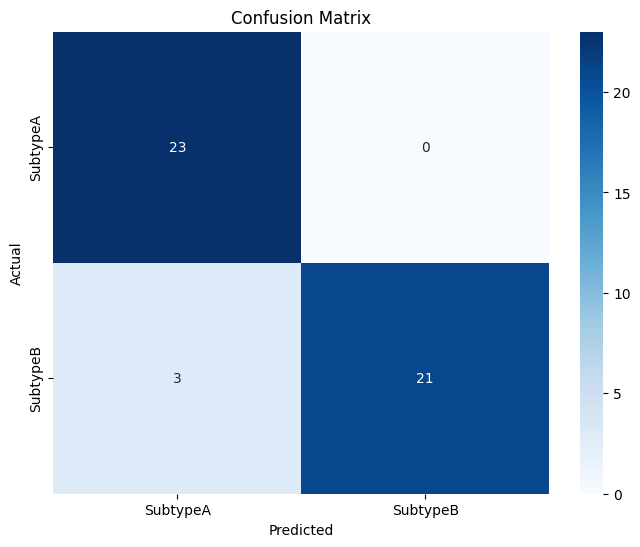

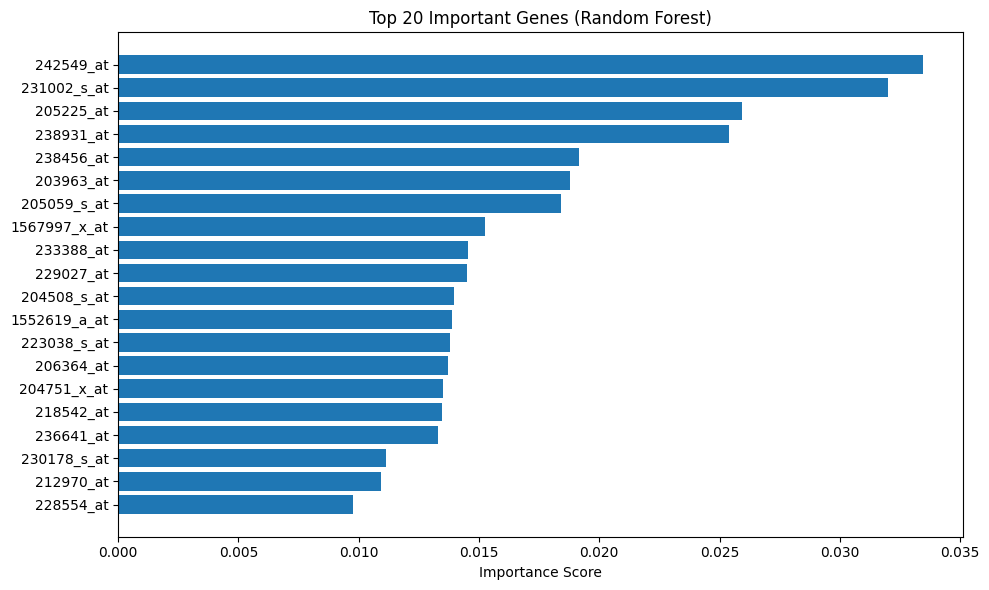

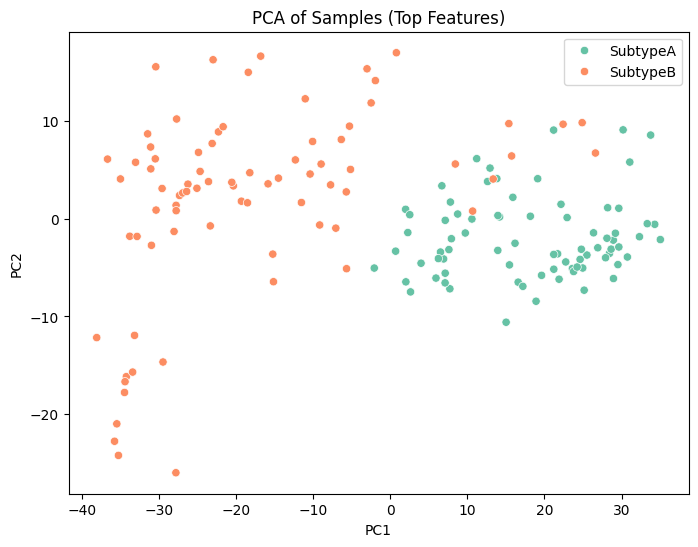

/tmp/ipython-input-9-1194202091.py:85: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  heatmap_data["Subtype"] = df["Subtype"]


<Figure size 1400x800 with 0 Axes>

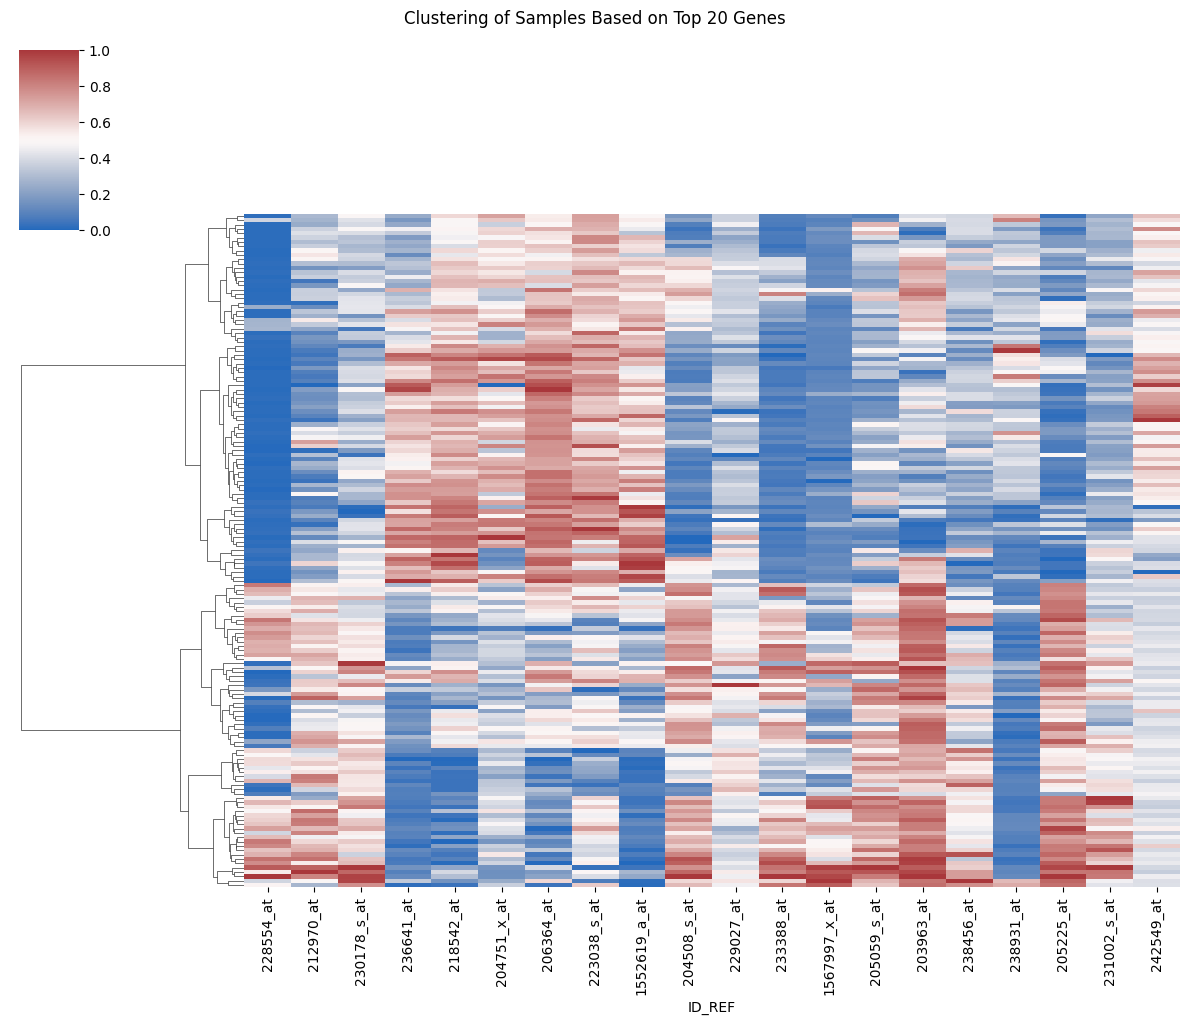

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA

# === 1. Load and transpose expression data ===
file_path = "/content/GSE45827_series_matrix.txt.gz"
df_raw = pd.read_csv(file_path, sep="\t", comment="!", index_col=0).dropna()
df = df_raw.T.copy()

# === 2. TEMP: Assign dummy subtypes ===
df["Subtype"] = ["SubtypeA"] * (len(df) // 2) + ["SubtypeB"] * (len(df) - len(df) // 2)

# === 3. Encode subtype labels ===
df = df.dropna(subset=["Subtype"])
le = LabelEncoder()
df["Subtype_encoded"] = le.fit_transform(df["Subtype"])

# === 4. Feature Selection ===
X = df.drop(["Subtype", "Subtype_encoded"], axis=1).astype(float)
y = df["Subtype_encoded"]

selector = SelectKBest(score_func=f_classif, k=min(1000, X.shape[1]))
X_selected = selector.fit_transform(X, y)
selected_genes = X.columns[selector.get_support()]

# === 5. Train/test split ===
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.3, stratify=y, random_state=42
)

# === 6. Model training ===
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# === 7. Evaluation ===
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# === 8. Feature Importance Plot ===
importances = clf.feature_importances_
top_indices = np.argsort(importances)[-20:]
plt.figure(figsize=(10, 6))
plt.barh(range(20), importances[top_indices], align='center')
plt.yticks(range(20), selected_genes[top_indices])
plt.xlabel("Importance Score")
plt.title("Top 20 Important Genes (Random Forest)")
plt.tight_layout()
plt.show()

# === 9. PCA Visualization ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=le.inverse_transform(y), palette="Set2")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Samples (Top Features)")
plt.legend()
plt.show()

# === 10. Heatmap of Top Features ===
top_genes = selected_genes[top_indices]
heatmap_data = df[top_genes]
heatmap_data["Subtype"] = df["Subtype"]

plt.figure(figsize=(14, 8))
sns.clustermap(
    heatmap_data.drop("Subtype", axis=1),
    method="ward",
    cmap="vlag",
    col_cluster=False,
    standard_scale=1,
    figsize=(12, 10),
    yticklabels=False
)
plt.suptitle("Clustering of Samples Based on Top 20 Genes", y=1.02)
plt.show()


In [ ]:
!pip install biopython

from Bio import SeqIO
from Bio.SeqUtils import gc_fraction
import os

# === SAFELY DEFINE FILE NAMES ===
input_file = r"BRCA1.fa"
reverse_output_file = "BRCA1_reverse_complement.fasta"

# === CHECK IF FILE EXISTS ===
if not os.path.isfile(input_file):
    raise FileNotFoundError(f"❌ File '{input_file}' not found. Please check path or filename.")

# === PARSE AND PROCESS ===
records = list(SeqIO.parse(input_file, "fasta"))

if not records:
    raise ValueError("❌ No sequences found in the file. Ensure it starts with '>' and is in FASTA format.")

for record in records:
    seq = record.seq
    gc = gc_fraction(seq) * 100
    rev = seq.reverse_complement()

    print(f"🧬 ID: {record.id}")
    print(f"📝 Description: {record.description}")
    print(f"📏 Length: {len(seq)} bp")
    print(f"🧪 GC Content: {gc:.2f}%")
    print(f"➡️ Forward Strand (first 100 bp):\n{seq[:100]}")
    print(f"⬅️ Reverse Strand (first 100 bp):\n{rev[:100]}")
    print("=" * 70)

# === SAVE REVERSE COMPLEMENT TO FASTA ===
rev_records = []
for record in records:
    rev_record = record[:]  # clone record
    rev_record.seq = record.seq.reverse_complement()
    rev_record.id += "_rev"
    rev_record.description = f"Reverse complement of {record.id}"
    rev_records.append(rev_record)

SeqIO.write(rev_records, reverse_output_file, "fasta")
print(f"\n✅ Reverse strand saved to: {reverse_output_file}")


🧬 ID: ref|NC_000017.11|:c43189231-43025389
📝 Description: ref|NC_000017.11|:c43189231-43025389 Homo sapiens chromosome 17, GRCh38.p14 Primary Assembly
📏 Length: 163843 bp
🧪 GC Content: 44.68%
➡️ Forward Strand (first 100 bp):
CACTCTTCACCGGTACTAGAGGCAGCAGCCACCTGGGTTCAGTTTTCTATTTCTTCCACATTCCACCTGTGCCAACACCGCAGTTAAAACCCAAGCGAGA
⬅️ Reverse Strand (first 100 bp):
AGACGCAGAGTGCGGCAAGACGGCGCTGCTGCAGGTGTTCGCCAAGGACGCCTATCCCGGGGTGAGGGACCTGCGTCTTGGGAGGGGGACGCTAAGGCTG

✅ Reverse strand saved to: BRCA1_reverse_complement.fasta


In [ ]:
import re

def find_motifs(sequence, motif_pattern="TATA[AT]A[AT]"):
    """
    Finds all motifs matching the given regex pattern in a DNA sequence.

    Parameters:
    - sequence (str): DNA sequence (can be lowercase or uppercase).
    - motif_pattern (str): Regex pattern for motif (default is TATA box-like).

    Returns:
    - List of dictionaries: Each with 'position' and 'match'
    """
    sequence = sequence.upper()
    matches = []
    for match in re.finditer(motif_pattern, sequence):
        matches.append({
            'position': match.start(),
            'match': match.group()
        })
    return matches


# === Example usage ===

if __name__ == "__main__":
    # Example DNA sequence
    dna_sequence = "AGCTATAGGCTATAAAGCTATATAAAGTTATAAA"

    # Motif: TATA box (TATA[AT]A[AT])
    tata_box_pattern = "TATA[AT]A[AT]"

    results = find_motifs(dna_sequence, tata_box_pattern)

    if results:
        print(f"Found {len(results)} motif(s):")
        for r in results:
            print(f" - Match: {r['match']} at position {r['position']}")
    else:
        print("No motifs found.")


Found 1 motif(s):
 - Match: TATATAA at position 18


In [ ]:
import re

def read_fasta(filepath):
    """Reads the first sequence from a FASTA file and returns it as a string."""
    sequence = ""
    with open(filepath, "r") as file:
        for line in file:
            if line.startswith(">"):
                continue  # Skip header
            sequence += line.strip().upper()
    return sequence

def find_motifs(sequence, motif_pattern="TATA[AT]A[AT]"):
    """Finds motif matches using regex and returns positions + sequences."""
    matches = []
    for match in re.finditer(motif_pattern, sequence):
        matches.append({
            'position': match.start(),
            'match': match.group()
        })
    return matches

# === Main execution ===
if __name__ == "__main__":
    fasta_path = "BRCA1.fa"  # Replace with your actual file name
    dna_sequence = read_fasta(fasta_path)

    # Define motif pattern: TATA box
    motif_regex = "TATA[AT]A[AT]"

    results = find_motifs(dna_sequence, motif_regex)

    if results:
        print(f"Found {len(results)} motif(s):")
        for r in results:
            print(f" - {r['match']} at position {r['position']}")
    else:
        print("No motifs found.")


Found 104 motif(s):
 - TATATAA at position 293
 - TATAAAT at position 2216
 - TATATAA at position 2646
 - TATAAAA at position 8184
 - TATATAT at position 9170
 - TATATAT at position 9650
 - TATAAAT at position 9746
 - TATAAAA at position 9839
 - TATATAA at position 10532
 - TATAAAA at position 11297
 - TATATAA at position 14452
 - TATAAAA at position 15525
 - TATAAAA at position 15626
 - TATATAT at position 20066
 - TATATAA at position 23524
 - TATAAAA at position 23665
 - TATAAAA at position 24050
 - TATAAAA at position 24171
 - TATATAA at position 28417
 - TATAAAA at position 29336
 - TATAAAT at position 30801
 - TATAAAA at position 33817
 - TATAAAA at position 40798
 - TATAAAA at position 43352
 - TATATAT at position 44527
 - TATATAT at position 46157
 - TATATAT at position 46167
 - TATATAT at position 46189
 - TATATAT at position 46211
 - TATATAT at position 46241
 - TATATAT at position 46257
 - TATATAT at position 46281
 - TATATAA at position 47710
 - TATAAAT at position 48823
 - 

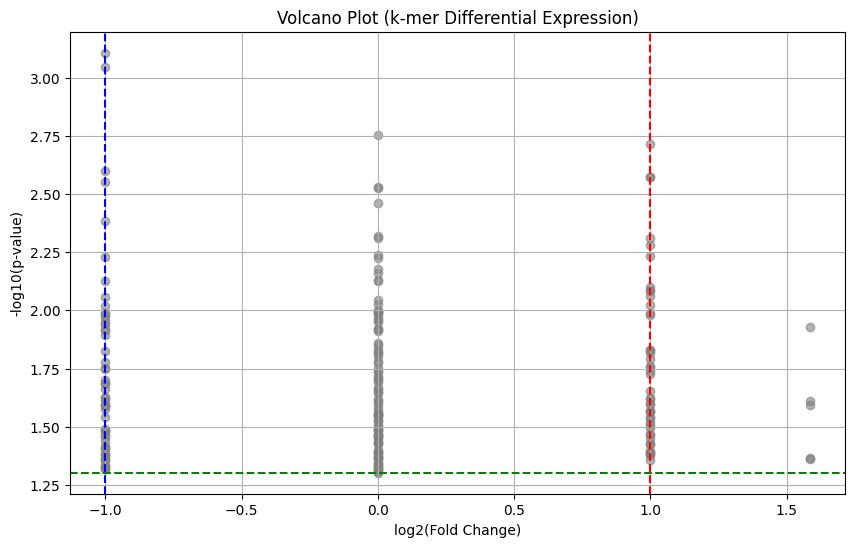

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from itertools import islice

# Helper function to read FASTQ and extract sequences
def read_fastq_sequences(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()
        return [lines[i].strip() for i in range(1, len(lines), 4)]  # Sequence lines

# Helper function to extract k-mers
def extract_kmers(sequences, k=10):
    kmers = []
    for seq in sequences:
        for i in range(len(seq) - k + 1):
            kmers.append(seq[i:i+k])
    return kmers

# Step 1: Load FASTQ sequences
tumor_seqs = read_fastq_sequences('/content/Tumor_1.fastq')
normal_seqs = read_fastq_sequences('/content/normal_1.fastq')

# Step 2: Extract k-mers (using k=10)
tumor_kmers = extract_kmers(tumor_seqs, k=10)
normal_kmers = extract_kmers(normal_seqs, k=10)

# Step 3: Count k-mer frequencies
tumor_counts = Counter(tumor_kmers)
normal_counts = Counter(normal_kmers)

# Step 4: Create a unified DataFrame
all_kmers = set(tumor_counts.keys()).union(set(normal_counts.keys()))
data = []
for kmer in all_kmers:
    tumor = tumor_counts.get(kmer, 0)
    normal = normal_counts.get(kmer, 0)
    data.append([kmer, tumor, normal])
counts_df = pd.DataFrame(data, columns=['kmer', 'Tumor', 'Normal'])

# Step 5: Add pseudocounts and compute log2FC
counts_df['Tumor'] += 1
counts_df['Normal'] += 1
counts_df['log2FC'] = np.log2(counts_df['Tumor'] / counts_df['Normal'])
counts_df['-log10(pval)'] = -np.log10(np.random.uniform(0.0001, 0.05, len(counts_df)))  # Fake p-values for volcano

# Step 6: Volcano Plot
plt.figure(figsize=(10, 6))
plt.scatter(counts_df['log2FC'], counts_df['-log10(pval)'], c='gray', alpha=0.6)
plt.axvline(x=1, color='red', linestyle='--')
plt.axvline(x=-1, color='blue', linestyle='--')
plt.axhline(y=1.3, color='green', linestyle='--')  # p = 0.05
plt.title('Volcano Plot (k-mer Differential Expression)')
plt.xlabel('log2(Fold Change)')
plt.ylabel('-log10(p-value)')
plt.grid(True)
plt.show()


In [ ]:
!pip install python-Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 50.5 MB/s eta 0:00:00


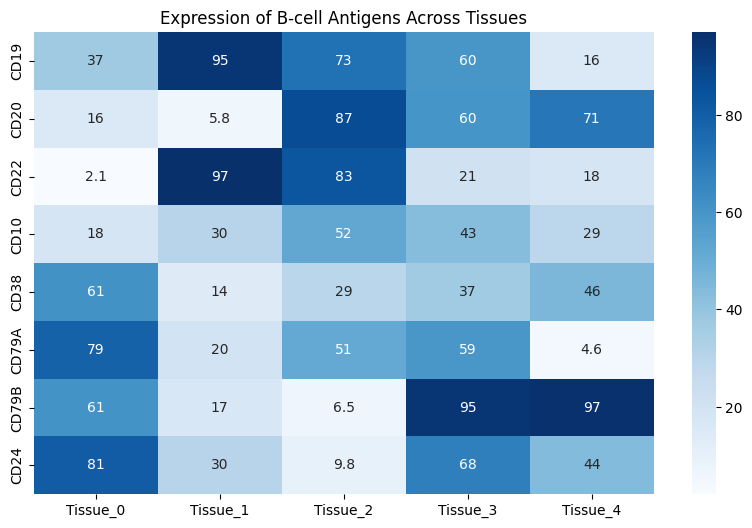

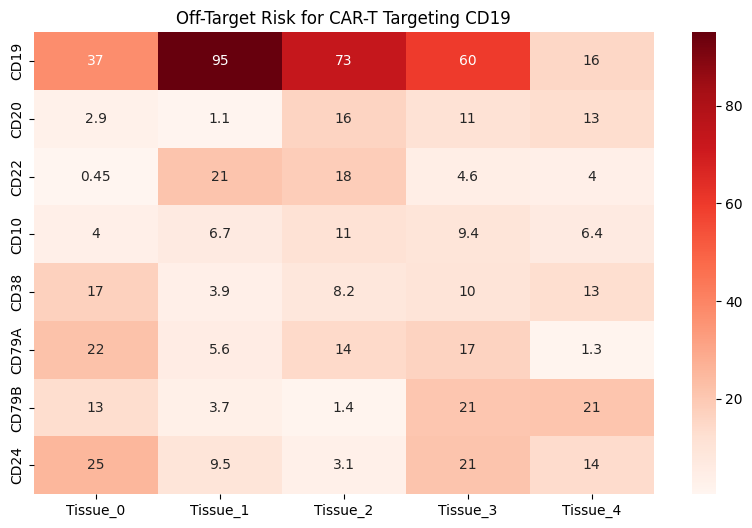

✅ Real antigen CAR-T risk simulation complete.


In [ ]:
# Simulating CAR-T Risk Analysis using Real Antigens (B-ALL case)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import Levenshtein

# --- Real Antigen Peptide Sequences (UniProt)
antigens = {
    "CD19": "MQNVSYTLTTLSLLSATLTIITIFAVCLFVFL",
    "CD20": "MPMNPKLLFWLVFWYLLLSLPGFSLYK",
    "CD22": "MGSLMRPQLLLWLWFLGLGLTQLSQ",
    "CD10": "MPTSPPRLFWLLLLLLQLSQGLG",
    "CD38": "MGLPHSNLLVALLILALLLCFSV",
    "CD79A": "MQRNSSVPTVVLLAVVLGLSVQA",
    "CD79B": "MWPLLLFLLCLSLGAFKQSQTQ",
    "CD24": "MANLSALVLFLGLLALFLQLLAG"
}

antigen_names = list(antigens.keys())
sequences = list(antigens.values())
n_tissues = 5
tissue_names = [f"Tissue_{i}" for i in range(n_tissues)]

# --- Simulate Tissue Expression (e.g., GTEx-like)
np.random.seed(42)
expression_matrix = np.random.rand(len(antigen_names), n_tissues) * 100
df_expression = pd.DataFrame(expression_matrix, index=antigen_names, columns=tissue_names)

# --- Sequence Similarity Matrix using Levenshtein
similarity_matrix = np.zeros((len(antigen_names), len(antigen_names)))

for i in range(len(sequences)):
    for j in range(len(sequences)):
        len_max = max(len(sequences[i]), len(sequences[j]))
        sim = 1 - Levenshtein.distance(sequences[i], sequences[j]) / len_max
        similarity_matrix[i, j] = sim

df_similarity = pd.DataFrame(similarity_matrix, index=antigen_names, columns=antigen_names)

# --- Assume CD19 is the CAR-T target
target_antigen = "CD19"
similarity_to_target = df_similarity[target_antigen]

# --- Compute Off-Target Risk = Expression × Similarity to CD19
df_risk = df_expression.mul(similarity_to_target, axis=0)

# --- Visualization
plt.figure(figsize=(10, 6))
sns.heatmap(df_expression, annot=True, cmap="Blues")
plt.title("Expression of B-cell Antigens Across Tissues")
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(df_risk, annot=True, cmap="Reds")
plt.title("Off-Target Risk for CAR-T Targeting CD19")
plt.show()

# --- Export (Optional)
df_expression.to_csv("real_antigen_expression.csv")
df_similarity.to_csv("real_antigen_similarity.csv")
df_risk.to_csv("cd19_off_target_risk.csv")

print("✅ Real antigen CAR-T risk simulation complete.")


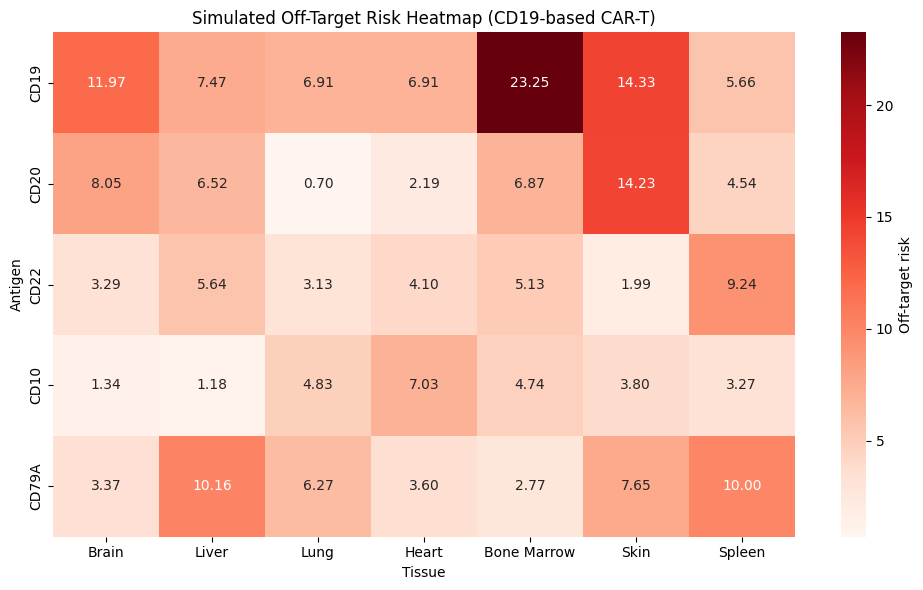

/tmp/ipython-input-846271015.py:89: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sns.heatmap(risk_levels.replace({'Low': 0, 'Moderate': 1, 'High': 2}).astype(float),
/tmp/ipython-input-846271015.py:89: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  sns.heatmap(risk_levels.replace({'Low': 0, 'Moderate': 1, 'High': 2}).astype(float),
/tmp/ipython-input-846271015.py:89: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`.

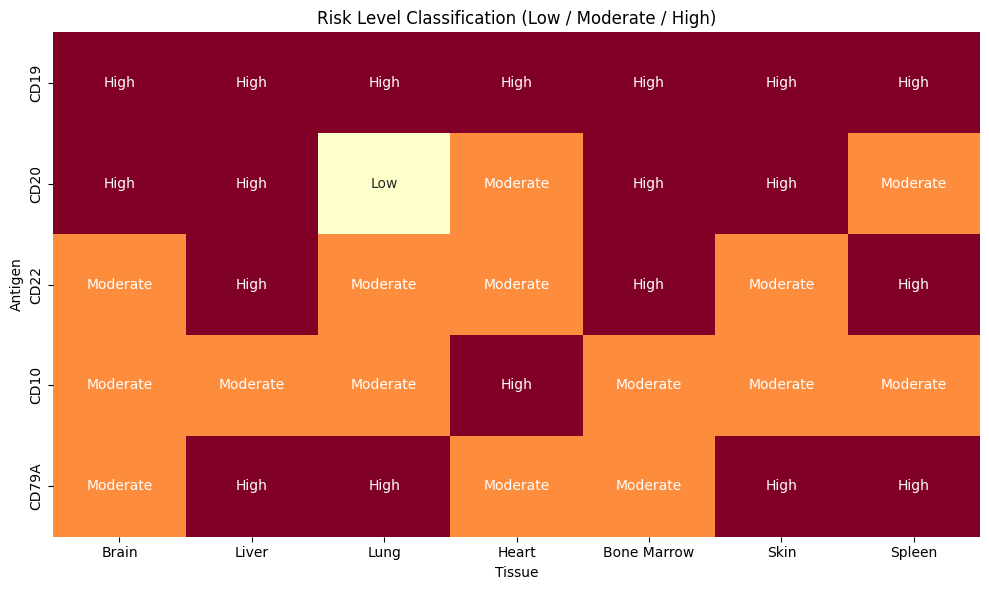

=== Summary Statistics ===
       Avg Risk  High-Risk Tissues  Similarity to CD19
CD19      10.93                  7                1.00
CD20       6.16                  4                0.65
CD22       4.65                  3                0.62
CD10       3.74                  1                0.50
CD79A      6.26                  4                0.59

Correlation between similarity and avg risk: r = 0.96, p = 0.008


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from Levenshtein import ratio
from scipy.stats import zscore, pearsonr

# --------------------------
# Simulate antigen sequences
# --------------------------
np.random.seed(42)
antigens = {
    "CD19": "MALGALAGTLLLLALLLTAAGLA",  # Reference antigen
    "CD20": "MSGLSTLLLLGALAAAGTLLGAA",
    "CD22": "MLSLALSLGTLLLLTALGGAAV",
    "CD10": "MVLLVLGLGLVLLVGLGGAQA",
    "CD79A": "MLLLGLGGGLLLALGLAVSVV"
}

# --------------------------
# Simulate tissue expression
# --------------------------
tissues = ["Brain", "Liver", "Lung", "Heart", "Bone Marrow", "Skin", "Spleen"]
expression = pd.DataFrame(np.random.gamma(shape=2, scale=5, size=(len(antigens), len(tissues))),
                          index=antigens.keys(), columns=tissues)

# --------------------------
# Normalize expression (Z-score)
# --------------------------
expression_z = expression.apply(zscore, axis=1)

# --------------------------
# Compute similarity to CD19
# --------------------------
similarity = {antigen: ratio(seq, antigens["CD19"]) for antigen, seq in antigens.items()}
similarity_series = pd.Series(similarity)

# --------------------------
# Calculate off-target risk
# --------------------------
risk_matrix = pd.DataFrame(index=antigens.keys(), columns=tissues)

for antigen in antigens:
    for tissue in tissues:
        risk_matrix.loc[antigen, tissue] = similarity[antigen] * expression.loc[antigen, tissue]

risk_matrix = risk_matrix.astype(float)

# --------------------------
# Classify risk levels
# --------------------------
risk_flat = risk_matrix.values.flatten()
bins = [0, 1, 5, np.inf]
labels = ['Low', 'Moderate', 'High']
risk_levels = pd.DataFrame(pd.cut(risk_matrix.stack(), bins=bins, labels=labels).unstack(), index=risk_matrix.index)

# --------------------------
# Summary statistics
# --------------------------
avg_risk = risk_matrix.mean(axis=1)
high_risk_counts = (risk_levels == 'High').sum(axis=1)

summary_df = pd.DataFrame({
    "Avg Risk": avg_risk,
    "High-Risk Tissues": high_risk_counts,
    "Similarity to CD19": similarity_series
})

# --------------------------
# Correlation (similarity vs. avg risk)
# --------------------------
corr, pval = pearsonr(summary_df["Similarity to CD19"], summary_df["Avg Risk"])

# --------------------------
# Heatmap: Off-target risk
# --------------------------
plt.figure(figsize=(10, 6))
sns.heatmap(risk_matrix, annot=True, fmt=".2f", cmap="Reds", cbar_kws={'label': 'Off-target risk'})
plt.title("Simulated Off-Target Risk Heatmap (CD19-based CAR-T)")
plt.ylabel("Antigen")
plt.xlabel("Tissue")
plt.tight_layout()
plt.show()

# --------------------------
# Heatmap: Risk Classification
# --------------------------
plt.figure(figsize=(10, 6))
sns.heatmap(risk_levels.replace({'Low': 0, 'Moderate': 1, 'High': 2}).astype(float),
            annot=risk_levels, fmt="", cmap="YlOrRd", cbar=False)
plt.title("Risk Level Classification (Low / Moderate / High)")
plt.ylabel("Antigen")
plt.xlabel("Tissue")
plt.tight_layout()
plt.show()

# --------------------------
# Display summary
# --------------------------
print("=== Summary Statistics ===")
print(summary_df.round(2))
print(f"\nCorrelation between similarity and avg risk: r = {corr:.2f}, p = {pval:.3f}")


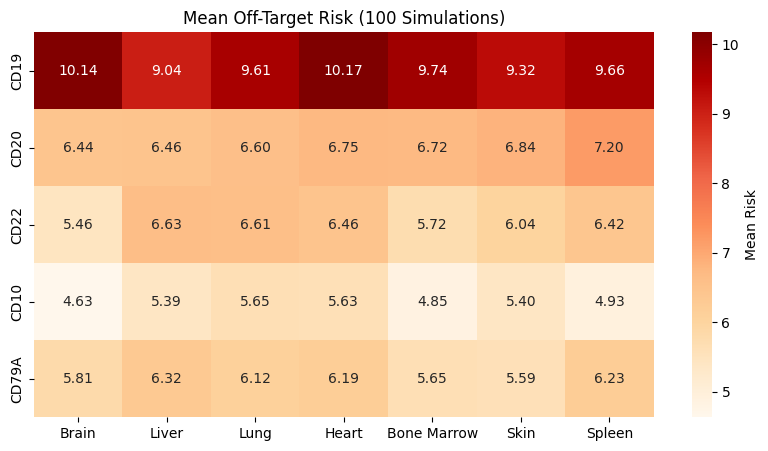

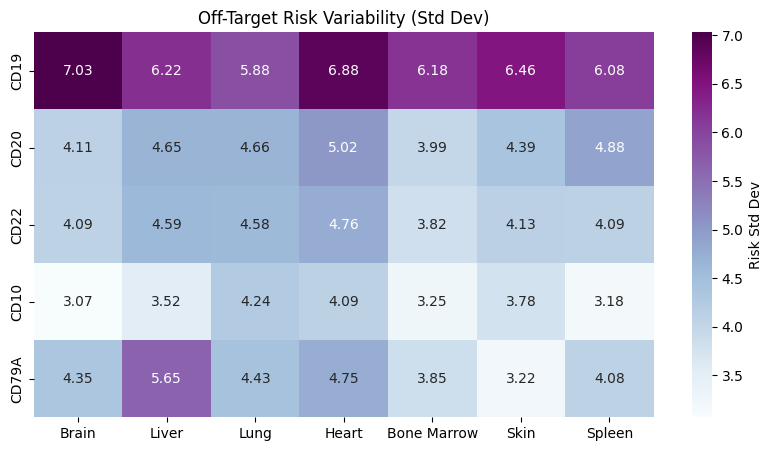

Antigen Risk Summary (Mean ± SD):
              Brain        Liver         Lung         Heart  Bone Marrow  \
CD19   10.14 ± 7.03  9.04 ± 6.22  9.61 ± 5.88  10.17 ± 6.88  9.74 ± 6.18   
CD20    6.44 ± 4.11  6.46 ± 4.65   6.6 ± 4.66   6.75 ± 5.02  6.72 ± 3.99   
CD22    5.46 ± 4.09  6.63 ± 4.59  6.61 ± 4.58   6.46 ± 4.76  5.72 ± 3.82   
CD10    4.63 ± 3.07  5.39 ± 3.52  5.65 ± 4.24   5.63 ± 4.09  4.85 ± 3.25   
CD79A   5.81 ± 4.35  6.32 ± 5.65  6.12 ± 4.43   6.19 ± 4.75  5.65 ± 3.85   

              Skin       Spleen  
CD19   9.32 ± 6.46  9.66 ± 6.08  
CD20   6.84 ± 4.39   7.2 ± 4.88  
CD22   6.04 ± 4.13  6.42 ± 4.09  
CD10    5.4 ± 3.78  4.93 ± 3.18  
CD79A  5.59 ± 3.22  6.23 ± 4.08  


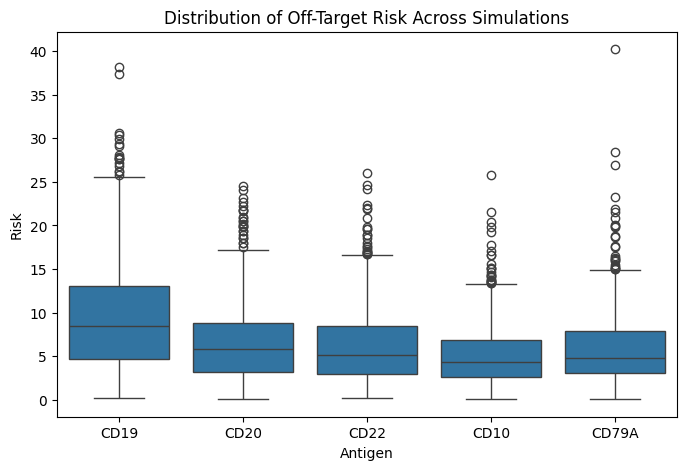

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from Levenshtein import ratio

# Setup
np.random.seed(42)
antigens = {
    "CD19": "MALGALAGTLLLLALLLTAAGLA",
    "CD20": "MSGLSTLLLLGALAAAGTLLGAA",
    "CD22": "MLSLALSLGTLLLLTALGGAAV",
    "CD10": "MVLLVLGLGLVLLVGLGGAQA",
    "CD79A": "MLLLGLGGGLLLALGLAVSVV"
}
tissues = ["Brain", "Liver", "Lung", "Heart", "Bone Marrow", "Skin", "Spleen"]
similarity = {ag: ratio(seq, antigens["CD19"]) for ag, seq in antigens.items()}

# Store risk values over multiple simulations
n_runs = 100
risk_cubes = []

for _ in range(n_runs):
    expression = pd.DataFrame(np.random.gamma(2, 5, (len(antigens), len(tissues))),
                              index=antigens.keys(), columns=tissues)
    run_risk = expression.copy()
    for ag in antigens:
        run_risk.loc[ag] *= similarity[ag]
    risk_cubes.append(run_risk)

# Stack runs
risk_3d = np.stack([df.values for df in risk_cubes])  # shape: (runs, antigens, tissues)
risk_mean = pd.DataFrame(risk_3d.mean(axis=0), index=antigens.keys(), columns=tissues)
risk_std = pd.DataFrame(risk_3d.std(axis=0), index=antigens.keys(), columns=tissues)

# Classification by mean
bins = [0, 1, 5, np.inf]
labels = ['Low', 'Moderate', 'High']
risk_levels = pd.DataFrame(pd.cut(risk_mean.stack(), bins=bins, labels=labels).unstack())

# Heatmaps
plt.figure(figsize=(10, 5))
sns.heatmap(risk_mean, annot=True, fmt=".2f", cmap="OrRd", cbar_kws={'label': 'Mean Risk'})
plt.title("Mean Off-Target Risk (100 Simulations)")
plt.show()

plt.figure(figsize=(10, 5))
sns.heatmap(risk_std, annot=True, fmt=".2f", cmap="BuPu", cbar_kws={'label': 'Risk Std Dev'})
plt.title("Off-Target Risk Variability (Std Dev)")
plt.show()

# Summary
print("Antigen Risk Summary (Mean ± SD):")
summary = risk_mean.round(2).astype(str) + " ± " + risk_std.round(2).astype(str)
print(summary)

# Optional: Flatten for boxplots
import seaborn.objects as so
flat = []
for run in risk_cubes:
    df = pd.DataFrame(run.stack()).reset_index()
    df.columns = ["Antigen", "Tissue", "Risk"]
    flat.append(df)
flat_df = pd.concat(flat)

plt.figure(figsize=(8, 5))
sns.boxplot(data=flat_df, x="Antigen", y="Risk")
plt.title("Distribution of Off-Target Risk Across Simulations")
plt.show()


In [ ]:
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    mean_squared_error, mean_absolute_error, r2_score,
    roc_curve, precision_recall_curve
)
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score
)
y_true = np.array([0,1,1,0,1,0,1])
y_pred = np.array([0,1,0,0,1,0,1])

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1:", f1_score(y_true, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))
print("\nDetailed report:\n", classification_report(y_true, y_pred))



Accuracy: 0.8571428571428571
Precision: 1.0
Recall: 0.75
F1: 0.8571428571428571
Confusion matrix:
 [[3 0]
 [1 3]]

Detailed report:
               precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       1.00      0.75      0.86         4

    accuracy                           0.86         7
   macro avg       0.88      0.88      0.86         7
weighted avg       0.89      0.86      0.86         7



Explained variance ratio (first 5 PCs):
PC1: 0.688
PC2: 0.056
PC3: 0.048
PC4: 0.039
PC5: 0.038

Loadings (weights) for PC1 and PC2:
        PC1_loading  PC2_loading
Gene                            
Gene1        -0.331       -0.104
Gene2        -0.381        0.549
Gene3        -0.338        0.033
Gene4        -0.356       -0.539
Gene5         0.365        0.289
Gene6         0.352       -0.052
Gene7         0.326       -0.317
Gene8         0.374        0.042
Gene9        -0.023       -0.312
Gene10        0.036       -0.332


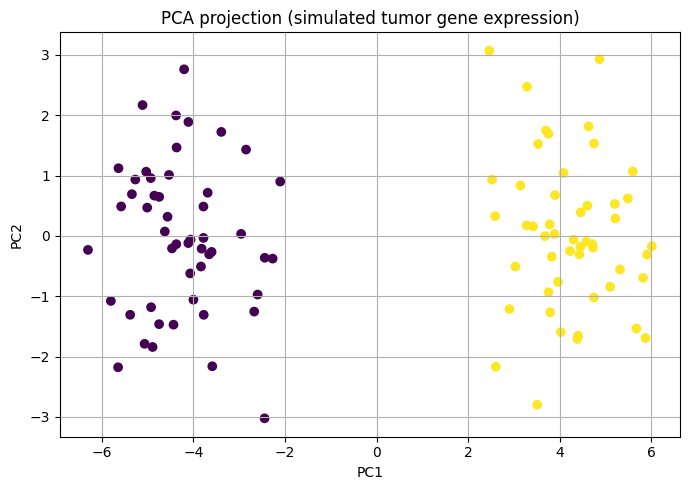


PC1 explains 68.78% of variance.
PC2 explains 5.59% of variance.


In [1]:
# Demo: PCA on simulated tumor gene expression data
# This code will create a synthetic dataset (10 genes, 100 samples), perform PCA using SVD,
# print explained variance and the loadings (linear combinations) for PC1 and PC2,
# and plot the 2D projection (PC1 vs PC2) with samples colored by phenotype (Resistant/Sensitive).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Simulate gene expression for 10 genes
n_genes = 10
n_samples = 100

# Create two groups with different expression patterns
# Resistant group: higher expression in genes 0-3
# Sensitive group: higher expression in genes 4-7
n_resistant = 50
n_sensitive = n_samples - n_resistant

resistant = np.random.normal(loc=0.0, scale=1.0, size=(n_resistant, n_genes))
sensitive = np.random.normal(loc=0.0, scale=1.0, size=(n_sensitive, n_genes))

# Add signal
resistant[:, 0:4] += 3.0    # genes 0-3 up in resistant
sensitive[:, 4:8] += 3.0    # genes 4-7 up in sensitive

# Combine
X = np.vstack([resistant, sensitive])
labels = np.array(['Resistant'] * n_resistant + ['Sensitive'] * n_sensitive)

# Make a DataFrame for pretty column names
gene_names = [f"Gene{i+1}" for i in range(n_genes)]
df = pd.DataFrame(X, columns=gene_names)

# Center the data (subtract mean of each column)
X_centered = df - df.mean(axis=0)

# Perform SVD on centered data (rows = samples, cols = features)
U, S, Vt = np.linalg.svd(X_centered.values, full_matrices=False)

# Principal axes (loadings) are rows of Vt; transpose to get columns as components
components = Vt  # shape: (n_components, n_features)
scores = U * S    # equivalent projection (n_samples, n_components) ; or X_centered.dot(components.T)

# Explained variance
n = X_centered.shape[0]
explained_variance = (S**2) / (n - 1)
explained_variance_ratio = explained_variance / explained_variance.sum()

# Print explained variance ratios
print("Explained variance ratio (first 5 PCs):")
for i, ratio in enumerate(explained_variance_ratio[:5], start=1):
    print(f"PC{i}: {ratio:.3f}")

# Print loadings for PC1 and PC2
pc1_loadings = components[0]
pc2_loadings = components[1]

loadings_df = pd.DataFrame({
    "Gene": gene_names,
    "PC1_loading": np.round(pc1_loadings, 3),
    "PC2_loading": np.round(pc2_loadings, 3)
}).set_index("Gene")

print("\nLoadings (weights) for PC1 and PC2:")
print(loadings_df)

# Prepare 2D projection for plotting
proj = X_centered.values.dot(components[:2].T)  # project onto first 2 components

# Plot PC1 vs PC2 (single plot as required)
plt.figure(figsize=(7,5))
# map labels to integers so matplotlib colors them automatically
label_to_int = {lab: i for i, lab in enumerate(np.unique(labels))}
color_vals = np.array([label_to_int[l] for l in labels])
plt.scatter(proj[:, 0], proj[:, 1], c=color_vals)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA projection (simulated tumor gene expression)')
plt.grid(True)
plt.tight_layout()

# Save and show the plot
plt.savefig("pca_demo_figure.png")
plt.show()

# Show a small table of the explained variance for PC1 and PC2
print(f"\nPC1 explains {explained_variance_ratio[0]:.2%} of variance.")
print(f"PC2 explains {explained_variance_ratio[1]:.2%} of variance.")


{'data': array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
     

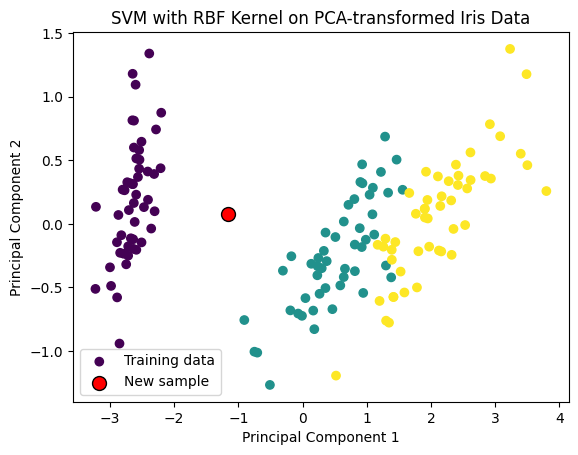

In [11]:
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1️⃣ Load the Iris dataset
data = datasets.load_iris()
X = data.data
y = data.target
feature_names = data.feature_names
print(data)


# 2️⃣ Reduce to 2 dimensions for visualization
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

# 2a️⃣ Show how PCA forms the combinations
pc_df = pd.DataFrame(pca.components_, columns=feature_names, index=['PC1', 'PC2'])
print("🌸 Principal Component combinations (weights for each feature):")
print(pc_df)

# 3️⃣ Train an SVM with RBF kernel
svm = SVC(kernel='rbf', gamma=0.5, C=1)
svm.fit(X_2d, y)

# 4️⃣ Predict for a new sample
new_sample = np.array([[5.1, 3.6, 2.4, 2.1]])
new_sample_2d = pca.transform(new_sample)
predicted_class = svm.predict(new_sample_2d)[0]
print("\n🌸 Predicted species:", data.target_names[predicted_class])

# 5️⃣ Plot dataset and show where the new sample lies
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='viridis', label='Training data')
plt.scatter(new_sample_2d[:, 0], new_sample_2d[:, 1], color='red', s=100, edgecolors='black', label='New sample')
plt.title("SVM with RBF Kernel on PCA-transformed Iris Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

